In [1]:
import pandas as pd
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:

def load_data(filename):
  return pd.read_csv('https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/covid19/'+filename)
dfcovid19 = load_data('countriessample.csv')
dfcovid19.head()


,Date,CountryRegion,Confirmed,Recovered,Deaths
0,1/22/2020,Ghana;Africa,NaN,NaN,0.0
1,1/22/2020,Greece;Europe,NaN,NaN,0.0
2,1/22/2020,Iceland;Europe,0.0,NaN,0.0
3,1/22/2020,India;Asia,0.0,NaN,0.0
4,1/22/2020,Indonesia;Asia,0.0,NaN,0.0


In [3]:

print("Số giá trị thiếu:\n", dfcovid19.isnull().sum())

Số giá trị thiếu:
 Date             0
CountryRegion    0
Confirmed        2
Recovered        8
Deaths           2
dtype: int64


In [4]:
df_imputed = dfcovid19.copy()

numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns
df_imputed[numeric_cols] = df_imputed[numeric_cols].fillna(df_imputed[numeric_cols].median())

print("Số giá trị thiếu sau khi xử lý:\n", df_imputed.isnull().sum())
df_imputed.head()

Số giá trị thiếu sau khi xử lý:
 Date             0
CountryRegion    0
Confirmed        0
Recovered        0
Deaths           0
dtype: int64


,Date,CountryRegion,Confirmed,Recovered,Deaths
0,1/22/2020,Ghana;Africa,1613.0,7405.5,0.0
1,1/22/2020,Greece;Europe,1613.0,7405.5,0.0
2,1/22/2020,Iceland;Europe,0.0,7405.5,0.0
3,1/22/2020,India;Asia,0.0,7405.5,0.0
4,1/22/2020,Indonesia;Asia,0.0,7405.5,0.0


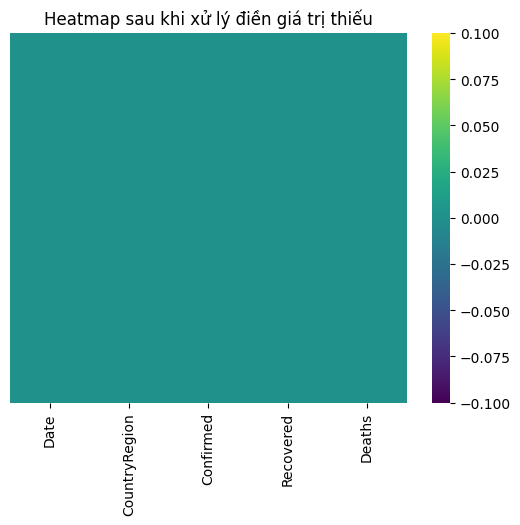

In [5]:
sns.heatmap(df_imputed.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis')
plt.title("Heatmap sau khi xử lý điền giá trị thiếu")
plt.show()

In [6]:
X = df_imputed[['Confirmed']].values
y = df_imputed[['Deaths']].values


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print("Dữ liệu X_train sau khi Scaler (5 dòng đầu):\n", X_train_scaled[:5])

Dữ liệu X_train sau khi Scaler (5 dòng đầu):
 [[-0.5022046 ]
 [ 1.918888  ]
 [-0.24852754]
 [-0.14233814]
 [-0.50203311]]


In [10]:
import torch

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

print("Chuẩn bị Tensor thành công. Kích thước X_train_t:", X_train_t.shape)

Chuẩn bị Tensor thành công. Kích thước X_train_t: torch.Size([14, 1])
